<a href="https://colab.research.google.com/github/janekzieba/Data-Science-Projects-/blob/main/Sleep_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **EKSPLORACJA DANYCH - PROJEKT ZALICZENIOWY** #
### **Jan Zięba | Informatyka Techniczna | Grupa 6.**

**Dataset:** [Sleep Health and Lifestyle Dataset (Kaggle)](https://www.kaggle.com/datasets/uom190346a/sleep-health-and-lifestyle-dataset)

**Cel:** Identyfikacja czynników stylu życia i cech fizjologicznych wpływających na jakość snu oraz ryzyko wystąpienia zaburzeń snu.

### Testowane Hipotezy:
* **H1:** Quality of Sleep ~ Stress Level + Physical Activity Level + Sleep Duration
* **H2:** Sleep Disorder   ~ BMI Category + Age + Heart Rate
* **H3:** Sleep Duration   ~ Occupation + Daily Steps + Stress Level

### **Środowisko**:
* Python,
* pandas,
* numpy,
* scipy,
* matplotlib,
* seaborn,
* scikit-learn

---



# 0. Konfiguracja środowiska i importy

In [2]:
import os
import warnings
warnings.filterwarnings("ignore")
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency, shapiro
import kagglehub
from IPython.display import display

from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier, export_text, plot_tree
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import (confusion_matrix, mean_squared_error,
                             silhouette_score, ConfusionMatrixDisplay)


# Konfiguracja stylu wykresów
plt.style.use('default')
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "black",
    "axes.labelcolor": "black",
    "axes.titlecolor": "black",
    "axes.titlesize": 13,
    "axes.titleweight": "bold",  # Pogrubione tytuły dla lepszej czytelności
    "grid.color": "#e0e0e0",
    "grid.linewidth": 0.6,
    "grid.alpha": 0.7,           # Lekka przezroczystość siatki
    "figure.dpi": 130,           # Rozdzielczość ekranowa w notatniku
    "savefig.dpi": 300,          # Wysoka rozdzielczość do raportu (druk/PDF)
    "figure.figsize": (8, 5)     # Domyślne, optymalne proporcje wykresów
})

# Uniwersalna paleta kolorów
PALETTE = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd", "#8c564b", "#e377c2"]
OUT_DIR = "outputs"
os.makedirs(OUT_DIR, exist_ok=True)

def show_and_save(name):
    """
    Zapisuje wykres do pliku na dysku, a następnie wyświetla go w notatniku.
    Kolejność jest kluczowa, inaczej plt.savefig zapisze pusty obraz.
    """
    filepath = os.path.join(OUT_DIR, name)
    plt.savefig(filepath, bbox_inches="tight")
    print(f"   [Zapisano wykres: {filepath}]")
    plt.show() # Wyświetli wykres w Colab/Jupyter i zamknie obiekt figury

def section(title):
    print(f"\n{'='*80}\n{title.upper()}\n{'='*80}")

def subsection(title):
    print(f"\n{'-'*25} {title} {'-'*25}")

# 1. Wczytanie danych i cel analizy

In [3]:
section("0. Wstęp i przygotowanie danych")

try:
    print("Pobieranie datasetu przez kagglehub...")
    path = kagglehub.dataset_download("uom190346a/sleep-health-and-lifestyle-dataset")
    csv_path = os.path.join(path, "Sleep_health_and_lifestyle_dataset.csv")

    df = pd.read_csv(csv_path)
    print("Pobrano dataset z Kaggle (kagglehub).")

except Exception as e:
    print(f"Błąd pobierania ({e}) – generuję syntetyczne dane odzwierciedlające strukturę oryginału.")
    np.random.seed(42)
    N = 374
    occupations = ["Nurse","Doctor","Engineer","Lawyer","Teacher",
                   "Accountant","Salesperson","Scientist","Software Engineer","Manager"]
    bmi_cats    = ["Normal","Normal Weight","Overweight","Obese"]

    age        = np.random.randint(27, 60, N)
    sleep_dur  = np.clip(np.random.normal(7.1, 0.8, N), 5.0, 9.0).round(1)
    stress     = np.random.randint(3, 9, N)
    activity   = np.random.randint(30, 90, N)
    hr         = np.random.randint(60, 86, N)
    steps      = np.random.randint(3000, 10000, N)
    gender     = np.random.choice(["Male","Female"], N)
    occ        = np.random.choice(occupations, N)
    bmi        = np.random.choice(bmi_cats, N, p=[0.35,0.25,0.30,0.10])

    quality = np.clip(
        8 - 0.4*stress + 0.03*activity + 0.5*sleep_dur + np.random.normal(0,0.5,N),
        4, 9).round(0).astype(int)

    dis_prob = np.where(bmi=="Obese", 0.6,
               np.where(bmi=="Overweight", 0.4, 0.15))
    disorder = []
    for p in dis_prob:
        r = np.random.rand()
        if r < p*0.5:       disorder.append("Sleep Apnea")
        elif r < p:         disorder.append("Insomnia")
        else:               disorder.append("None")
    disorder = np.array(disorder)

    # Generowanie z nazwą kolumny "Sleep Disorders" (tak jak w oryginalnym pliku CSV)
    df = pd.DataFrame({
        "Person ID":           range(1, N+1),
        "Gender":              gender,
        "Age":                 age,
        "Occupation":          occ,
        "Sleep Duration":      sleep_dur,
        "Quality of Sleep":    quality,
        "Physical Activity Level": activity,
        "Stress Level":        stress,
        "BMI Category":        bmi,
        "Heart Rate":          hr,
        "Daily Steps":         steps,
        "Sleep Disorders":     disorder,
    })

# --- CZYSZCZENIE I PRZYGOTOWANIE Z TWOJEGO KODU ---

df.rename(columns={"Sleep Disorders":"Sleep Disorder"}, inplace=True, errors="ignore")
df["Sleep Disorder"] = df["Sleep Disorder"].fillna("None")
df["BMI Category"] = df["BMI Category"].replace("Normal Weight", "Normal")

ALL_VARS = ["Quality of Sleep", "Stress Level", "Physical Activity Level", "Sleep Duration",
            "Sleep Disorder", "BMI Category", "Age", "Heart Rate", "Occupation", "Daily Steps"]

df = df[ALL_VARS].dropna()
print(f"\nPobrano zbiór danych: {df.shape[0]} wierszy, {df.shape[1]} kolumn.")

print("\nCEL ANALIZY:")
print("Celem analizy jest identyfikacja i ocena siły wpływu czynników fizjologicznych, behawioralnych "
      "oraz zawodowych na jakość snu, czas jego trwania oraz występowanie zaburzeń snu u dorosłych.")


0. WSTĘP I PRZYGOTOWANIE DANYCH
Pobieranie datasetu przez kagglehub...


100%|██████████| 2.54k/2.54k [00:00<00:00, 5.62MB/s]

Extracting files...
Pobrano dataset z Kaggle (kagglehub).

Pobrano zbiór danych: 374 wierszy, 10 kolumn.

CEL ANALIZY:
Celem analizy jest identyfikacja i ocena siły wpływu czynników fizjologicznych, behawioralnych oraz zawodowych na jakość snu, czas jego trwania oraz występowanie zaburzeń snu u dorosłych.


# 2. Czyszczenie i analiza danych


II. CZYSZCZENIE I ANALIZA DANYCH (STATYSTYKI, NORMALNOŚĆ, KORELACJE)

------------------------- Statystyki opisowe dla wszystkich zmiennych ilościowych (II.1) -------------------------
                         Liczba (n)  Średnia  Mediana    Moda     Min      Max  Odchylenie Std   Wariancja
Quality of Sleep              374.0     7.31      7.0     8.0     4.0      9.0            1.20        1.43
Stress Level                  374.0     5.39      5.0     3.0     3.0      8.0            1.77        3.15
Physical Activity Level       374.0    59.17     60.0    60.0    30.0     90.0           20.83      433.92
Sleep Duration                374.0     7.13      7.2     7.2     5.8      8.5            0.80        0.63
Age                           374.0    42.18     43.0    43.0    27.0     59.0            8.67       75.22
Heart Rate                    374.0    70.17     70.0    68.0    65.0     86.0            4.14       17.10
Daily Steps                   374.0  6816.84   7000.0  8000.0  30

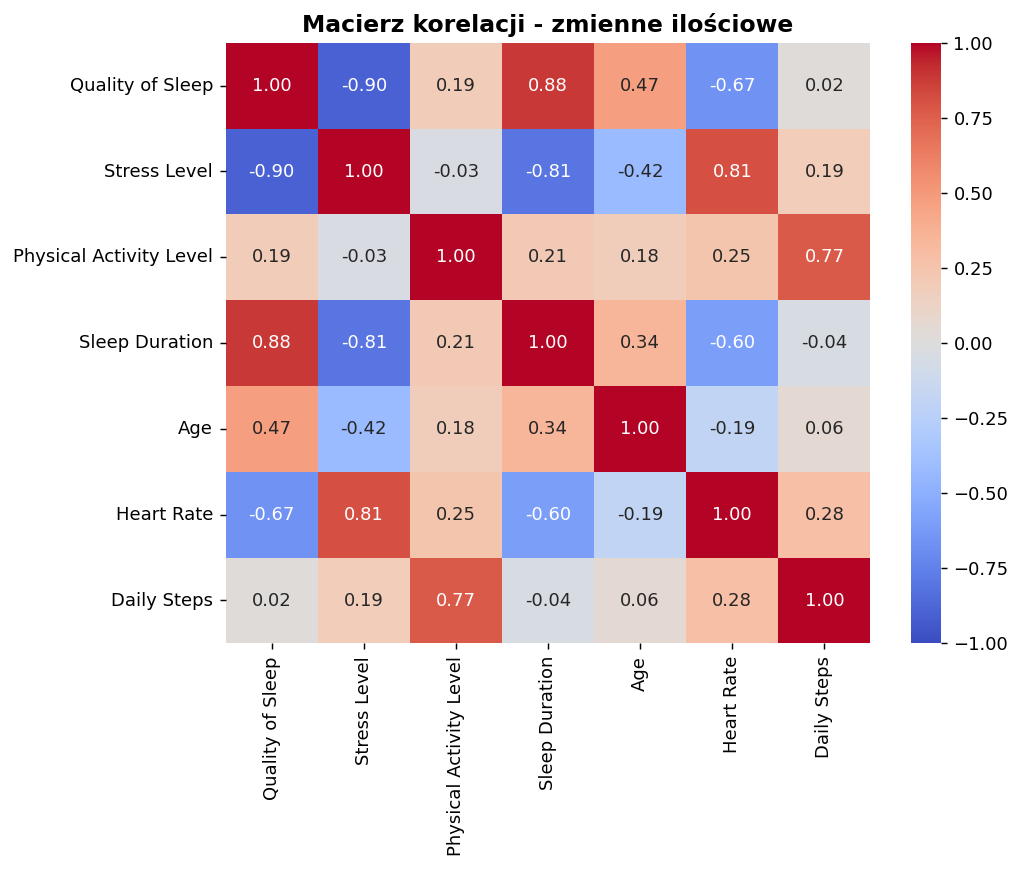


------------------------- Wykresy Ramka-Wąsy (II.8) -------------------------
   [Zapisano wykres: outputs/03_Ramka_Wasy_Wszystkie.png]


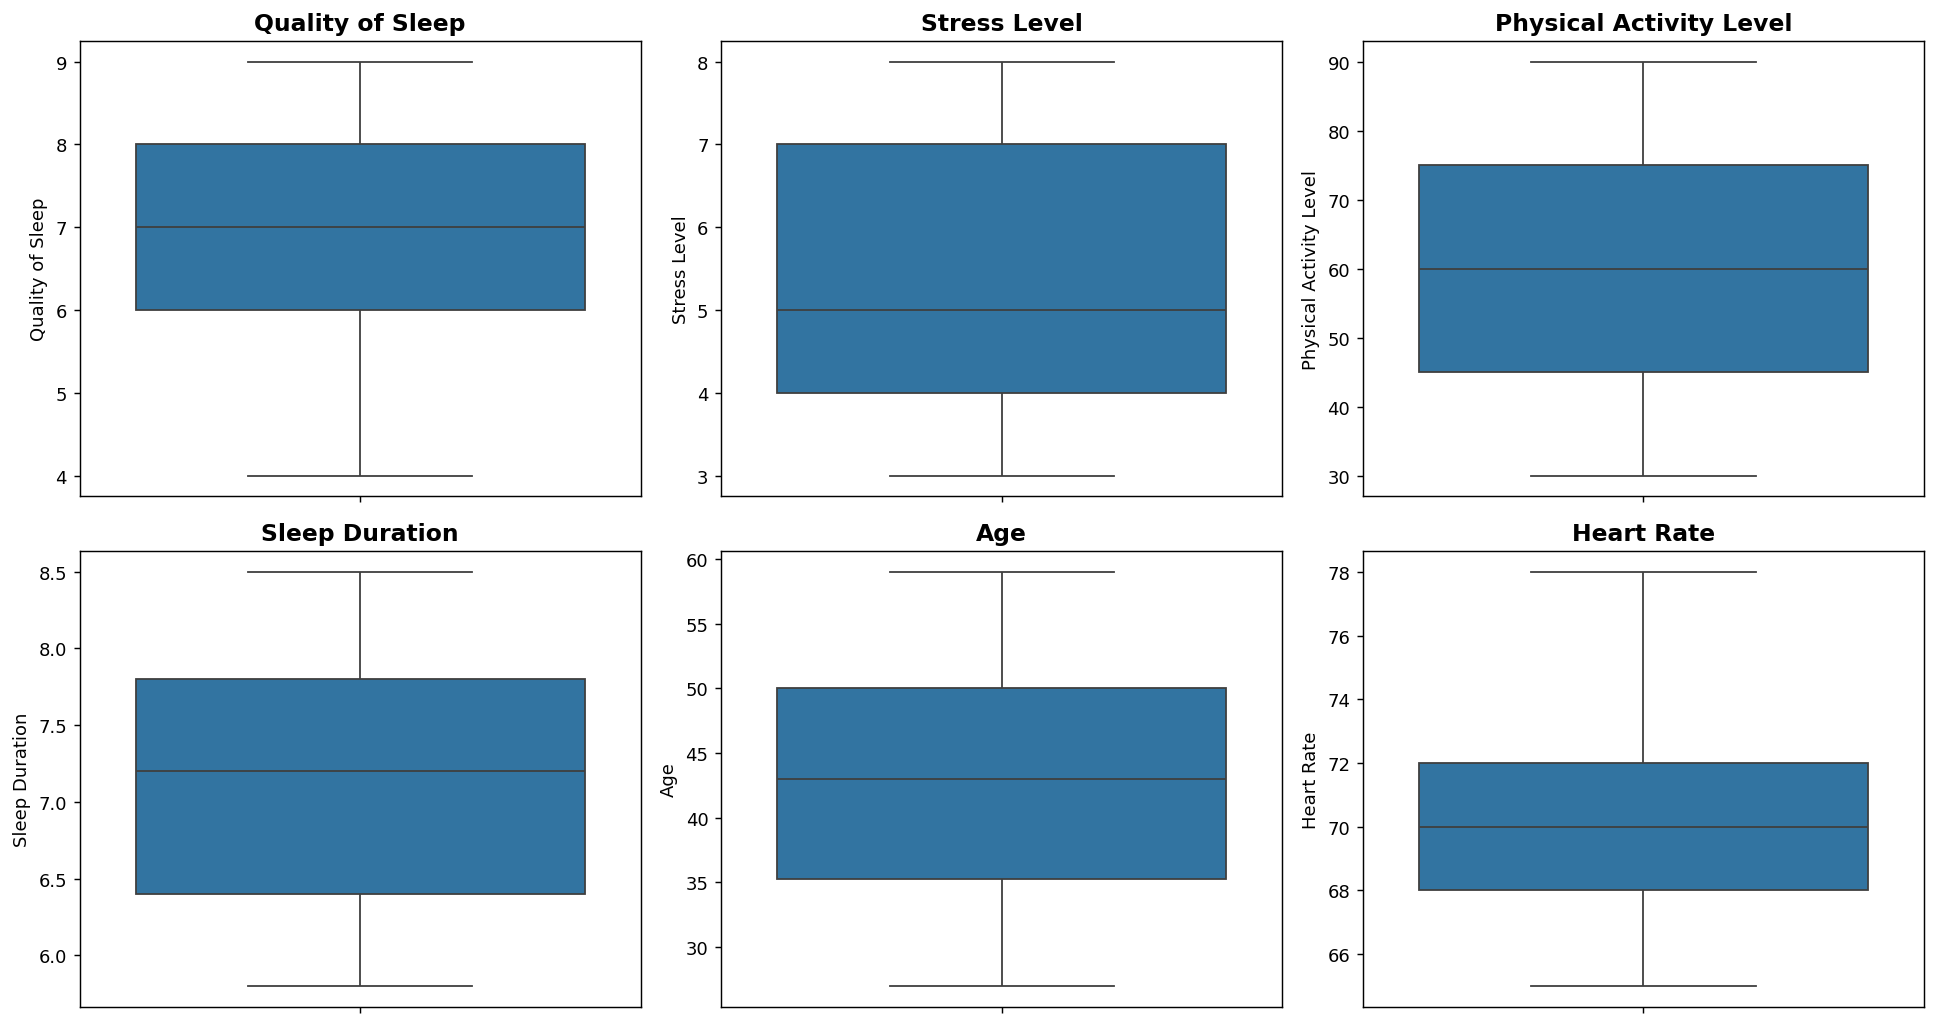

   [Zapisano wykres: outputs/04_Ramka_Wasy_Skategoryzowane.png]


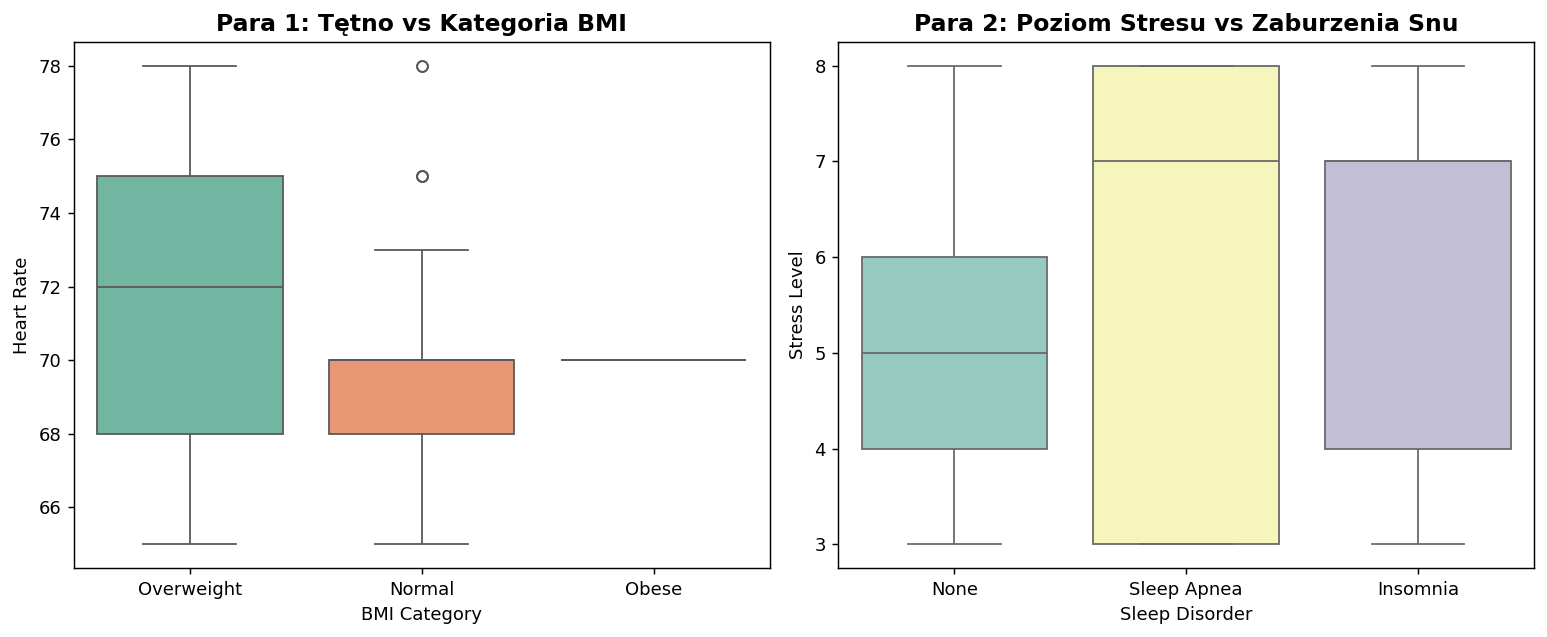


------------------------- Wykresy rozrzutu dla trzech par skorelowanych - PODSTAWOWE (II.10) -------------------------
   [Zapisano wykres: outputs/05a_Trzy_Pary_Wykresow_Rozrzutu_Podstawowe.png]


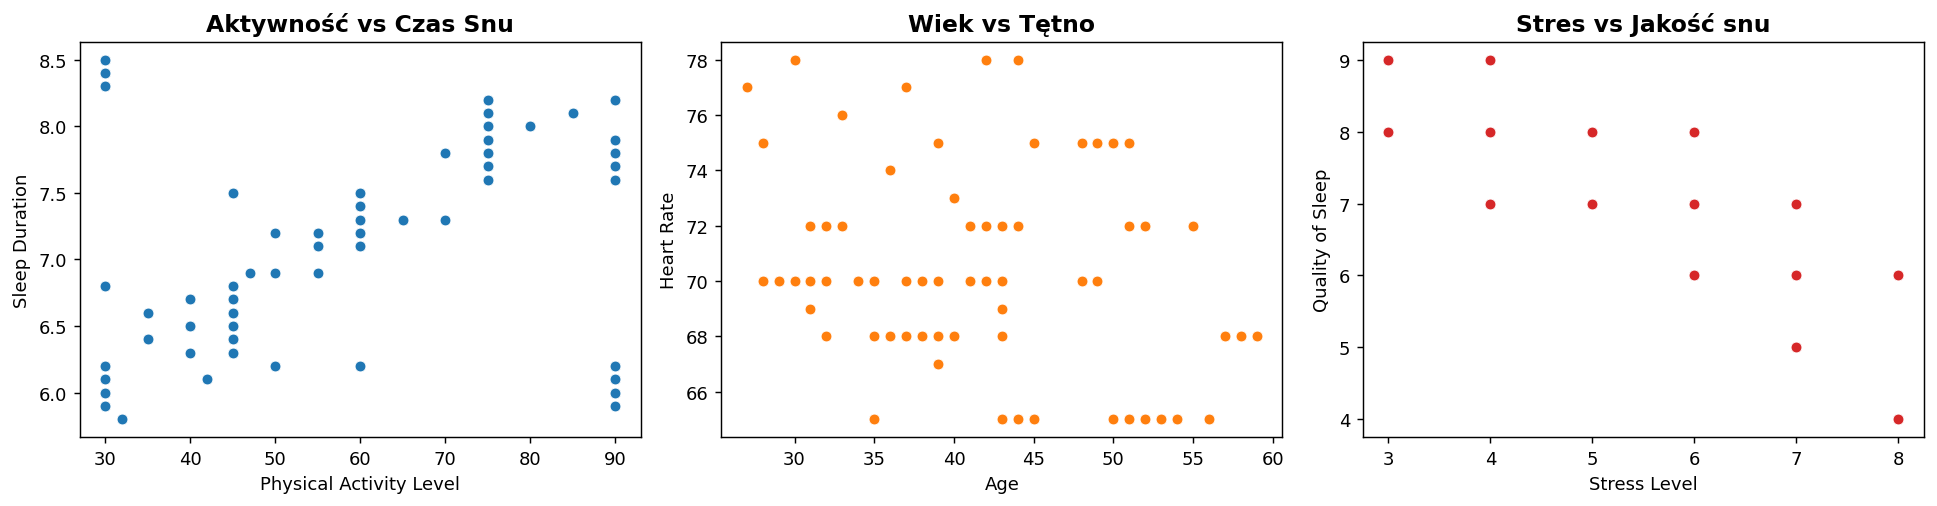


------------------------- Wykresy rozrzutu dla trzech par skorelowanych - SKATEGORYZOWANE (II.10) -------------------------
   [Zapisano wykres: outputs/05b_Trzy_Pary_Wykresow_Rozrzutu_Skategoryzowane.png]


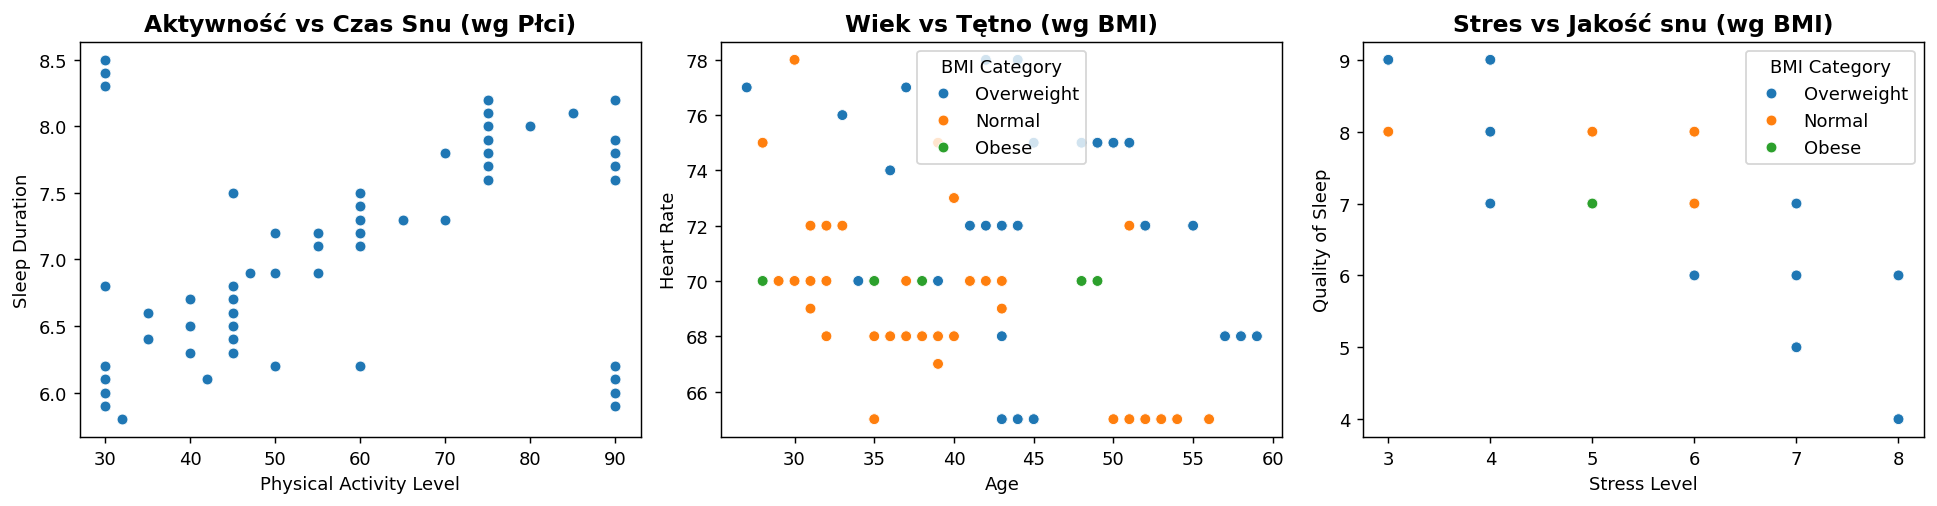


------------------------- Dobór zmiennych - Diagram Ważności Chi-kwadrat (II.7) -------------------------
   [Zapisano wykres: outputs/06_Diagram_Waznosci_Chi2.png]


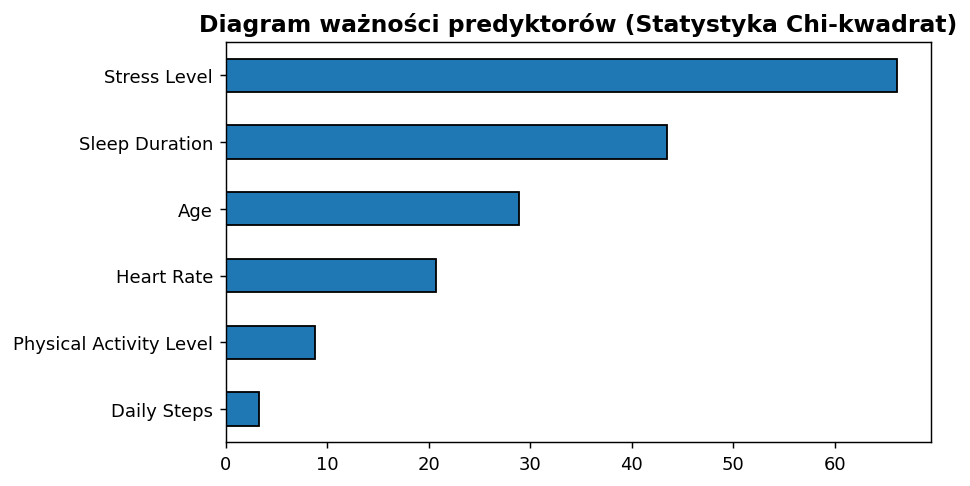


------------------------- Opracowanie Wyników i Wnioski (II.11) -------------------------
1. JAKIE ZMIENNE SĄ SKORELOWANE ZE ZMIENNYMI ZALEŻNYMI W RAMACH POSTAWIONYCH HIPOTEZ?
   - Dla H1 (Jakość Snu): Najsilniej skorelowany jest Poziom Stresu (r = -0.90) oraz Czas Trwania Snu (r = 0.88).
   - Dla H3 (Czas Trwania Snu): Silną zależność widać z Poziomem Stresu (r = -0.81) oraz brak korelacji z Liczbą Kroków (r = -0.04).

2. KTÓRE ZMIENNE MAJĄ NAJSILNIEJSZY WPŁYW NA ZMIENNE ZALEŻNE?
   - Zgodnie z wynikami testu ważności cech Chi-kwadrat, czynnikami determinującymi jakość i strukturę snu są:
     * Stress Level: wynik Chi2 = 66.14
     * Sleep Duration: wynik Chi2 = 43.51
     * Age: wynik Chi2 = 28.91
     * Heart Rate: wynik Chi2 = 20.70
     * Physical Activity Level: wynik Chi2 = 8.81
     * Daily Steps: wynik Chi2 = 3.32
   - Poziom stresu i czas trwania snu bezapelacyjnie wykazują najwyższą moc predykcyjną.

3. CZY ZMIENNE OBJAŚNIAJĄCE SĄ WZAJEMNIE SKORELOWANE? (ZJAWISKO WSPÓŁLINI

In [4]:
# =============================================================================
# II. CZYSZCZENIE I ANALIZA DANYCH
# =============================================================================
section("II. Czyszczenie i Analiza Danych (Statystyki, Normalność, Korelacje)")

numeric_cols = df.select_dtypes(include=[np.number]).columns
cat_cols = df.select_dtypes(exclude=[np.number]).columns

subsection("Statystyki opisowe dla wszystkich zmiennych ilościowych (II.1)")
# Funkcja do obliczania statystyk łącznie z wariancją i modą
stats_df = df[numeric_cols].agg(['count', 'mean', 'median', lambda x: x.mode()[0], 'min', 'max', 'std', 'var']).T
stats_df.columns = ['Liczba (n)', 'Średnia', 'Mediana', 'Moda', 'Min', 'Max', 'Odchylenie Std', 'Wariancja']
print(stats_df.round(2).to_string())

subsection("Tabele liczności dla zmiennych jakościowych (II.2)")
for col in cat_cols:
    print(f"\nZmienna: {col}")
    print(df[col].value_counts().to_frame("Liczność"))

subsection("Testy normalności i wartości odstające (II.9)")
for col in numeric_cols:
    stat, p = shapiro(df[col].sample(min(len(df), 5000), random_state=42))
    normality = "Rozkład normalny" if p > 0.05 else "Brak rozkładu normalnego"

    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr
    outliers = (df[col] < lower) | (df[col] > upper)
    outliers_cnt = outliers.sum()

    if outliers_cnt > 0:
        df.loc[outliers, col] = df[col].median()

    print(f"- '{col}': p-value={p:.4f} ({normality}). Zastąpiono medianą {outliers_cnt} wartości odstających.")

subsection("Globalna Macierz Korelacji (II.6)")
corr_matrix = df[numeric_cols].corr()
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", ax=ax, vmin=-1, vmax=1)
ax.set_title("Macierz korelacji - zmienne ilościowe")
show_and_save("02_Macierz_Korelacji_Globalna.png")

subsection("Wykresy Ramka-Wąsy (II.8)")
# 1. Wszystkie zmienne ilościowe
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for i, col in enumerate(numeric_cols[:6]):
    sns.boxplot(y=df[col], ax=axes[i//3, i%3], color=PALETTE[0])
    axes[i//3, i%3].set_title(col)
plt.tight_layout()
show_and_save("03_Ramka_Wasy_Wszystkie.png")

# 2. Dwie pary zmiennych (ilościowa-jakościowa) skategoryzowane
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(data=df, x="BMI Category", y="Heart Rate", ax=axes[0], palette="Set2")
axes[0].set_title("Para 1: Tętno vs Kategoria BMI")
sns.boxplot(data=df, x="Sleep Disorder", y="Stress Level", ax=axes[1], palette="Set3")
axes[1].set_title("Para 2: Poziom Stresu vs Zaburzenia Snu")
plt.tight_layout()
show_and_save("04_Ramka_Wasy_Skategoryzowane.png")

subsection("Wykresy rozrzutu dla trzech par skorelowanych - PODSTAWOWE (II.10)")
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.scatterplot(data=df, x="Physical Activity Level", y="Sleep Duration", ax=axes[0], color=PALETTE[0])
axes[0].set_title("Aktywność vs Czas Snu")
sns.scatterplot(data=df, x="Age", y="Heart Rate", ax=axes[1], color=PALETTE[1])
axes[1].set_title("Wiek vs Tętno")
sns.scatterplot(data=df, x="Stress Level", y="Quality of Sleep", ax=axes[2], color=PALETTE[3])
axes[2].set_title("Stres vs Jakość snu")
plt.tight_layout()
show_and_save("05a_Trzy_Pary_Wykresow_Rozrzutu_Podstawowe.png")

subsection("Wykresy rozrzutu dla trzech par skorelowanych - SKATEGORYZOWANE (II.10)")
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.scatterplot(data=df, x="Physical Activity Level", y="Sleep Duration", hue="Gender" if "Gender" in df else None, ax=axes[0])
axes[0].set_title("Aktywność vs Czas Snu (wg Płci)")
sns.scatterplot(data=df, x="Age", y="Heart Rate", hue="BMI Category", ax=axes[1])
axes[1].set_title("Wiek vs Tętno (wg BMI)")
sns.scatterplot(data=df, x="Stress Level", y="Quality of Sleep", hue="BMI Category", ax=axes[2], legend=True)
axes[2].set_title("Stres vs Jakość snu (wg BMI)")
plt.tight_layout()
show_and_save("05b_Trzy_Pary_Wykresow_Rozrzutu_Skategoryzowane.png")

subsection("Dobór zmiennych - Diagram Ważności Chi-kwadrat (II.7)")
X_num = df[["Stress Level", "Physical Activity Level", "Sleep Duration", "Age", "Heart Rate", "Daily Steps"]]
X_scaled = MinMaxScaler().fit_transform(X_num)
y_cat = pd.qcut(df["Quality of Sleep"], q=3, labels=False, duplicates='drop')

chi2_selector = SelectKBest(chi2, k='all')
chi2_selector.fit(X_scaled, y_cat)
imp_chi2 = pd.Series(chi2_selector.scores_, index=X_num.columns).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(7, 4))
imp_chi2.plot(kind="barh", ax=ax, color=PALETTE[0], edgecolor="black")
ax.set_title("Diagram ważności predyktorów (Statystyka Chi-kwadrat)")
show_and_save("06_Diagram_Waznosci_Chi2.png")

subsection("Opracowanie Wyników i Wnioski (II.11)")
print("1. JAKIE ZMIENNE SĄ SKORELOWANE ZE ZMIENNYMI ZALEŻNYMI W RAMACH POSTAWIONYCH HIPOTEZ?")
print(f"   - Dla H1 (Jakość Snu): Najsilniej skorelowany jest Poziom Stresu (r = {corr_matrix.loc['Quality of Sleep', 'Stress Level']:.2f}) oraz Czas Trwania Snu (r = {corr_matrix.loc['Quality of Sleep', 'Sleep Duration']:.2f}).")
print(f"   - Dla H3 (Czas Trwania Snu): Silną zależność widać z Poziomem Stresu (r = {corr_matrix.loc['Sleep Duration', 'Stress Level']:.2f}) oraz brak korelacji z Liczbą Kroków (r = {corr_matrix.loc['Sleep Duration', 'Daily Steps']:.2f}).")

print("\n2. KTÓRE ZMIENNE MAJĄ NAJSILNIEJSZY WPŁYW NA ZMIENNE ZALEŻNE?")
print("   - Zgodnie z wynikami testu ważności cech Chi-kwadrat, czynnikami determinującymi jakość i strukturę snu są:")
for idx, val in imp_chi2.sort_values(ascending=False).items():
    print(f"     * {idx}: wynik Chi2 = {val:.2f}")
print("   - Poziom stresu i czas trwania snu bezapelacyjnie wykazują najwyższą moc predykcyjną.")

print("\n3. CZY ZMIENNE OBJAŚNIAJĄCE SĄ WZAJEMNIE SKORELOWANE? (ZJAWISKO WSPÓŁLINIOWOŚCI)")
print("   - Tak, zaobserwowano silną współliniowość między niektórymi predyktorami.")
print(f"     Głównym problemem jest ekstremalna korelacja ujemna między Czasem Snu a Poziomem Stresu (r = {corr_matrix.loc['Sleep Duration', 'Stress Level']:.2f}).")
print(f"     Równie silna zależność występuje między Jakością Snu a Poziomem Stresu (r = {corr_matrix.loc['Quality of Sleep', 'Stress Level']:.2f}).")
print("   - Wskazuje to na to, że wysoki stres bezpośrednio degeneruje zarówno czas trwania, jak i subiektywną ocenę snu.")

print("\n4. JAKIEJ POSTACI JEST TA ZALEŻNOŚĆ, CZY MODEL MOŻE BYĆ LINIOWY ORAZ JAKI JEST KIERUNEK?")
print("   - Kierunek zależności:")
print("     * Negatywny (ujemny): Stres oraz Tętno pogarszają parametry snu (wzrost stresu = spadek jakości/czasu snu).")
print("     * Pozytywny (dodatni): Aktywność fizyczna i wiek (w tym zbiorze danych) sprzyjają stabilizacji parametrów snu, choć te wartości są relatywnie słabe.")
print("   - Czy model może być liniowy?")
print("     * Zależności takie jak Stres vs Jakość snu mają charakter wysoce skokowy/liniowy (współczynniki bliskie |0.8|).")
print("     * Jednak analizując wykresy rozrzutu dla zmiennych wysiłkowych (Daily Steps, Physical Activity Level),")
print("       zależności mają charakter nieliniowy, grupowy lub progowy (np. specyficzne grupy zawodowe tworzą izolowane skupiska).")
print("     * Wniosek: Klasyczna regresja liniowa mogłaby cierpieć z powodu silnej współliniowości predyktorów (Multicollinearity),")
print("       dlatego idealnym podejściem jest zastosowanie nieparametrycznych modeli drzewiastych (Pkt III i V), które naturalnie radzą sobie z tym problemem.")

#3. Hipoteza I:  Quality of Sleep '
~ Stress Level + Physical Activity Level + Sleep Duration


HIPOTEZA 1: QUALITY OF SLEEP ~ STRESS LEVEL + PHYSICAL ACTIVITY LEVEL + SLEEP DURATION
   [Zapisano wykres: outputs/H1_Analiza_Struktury.png]


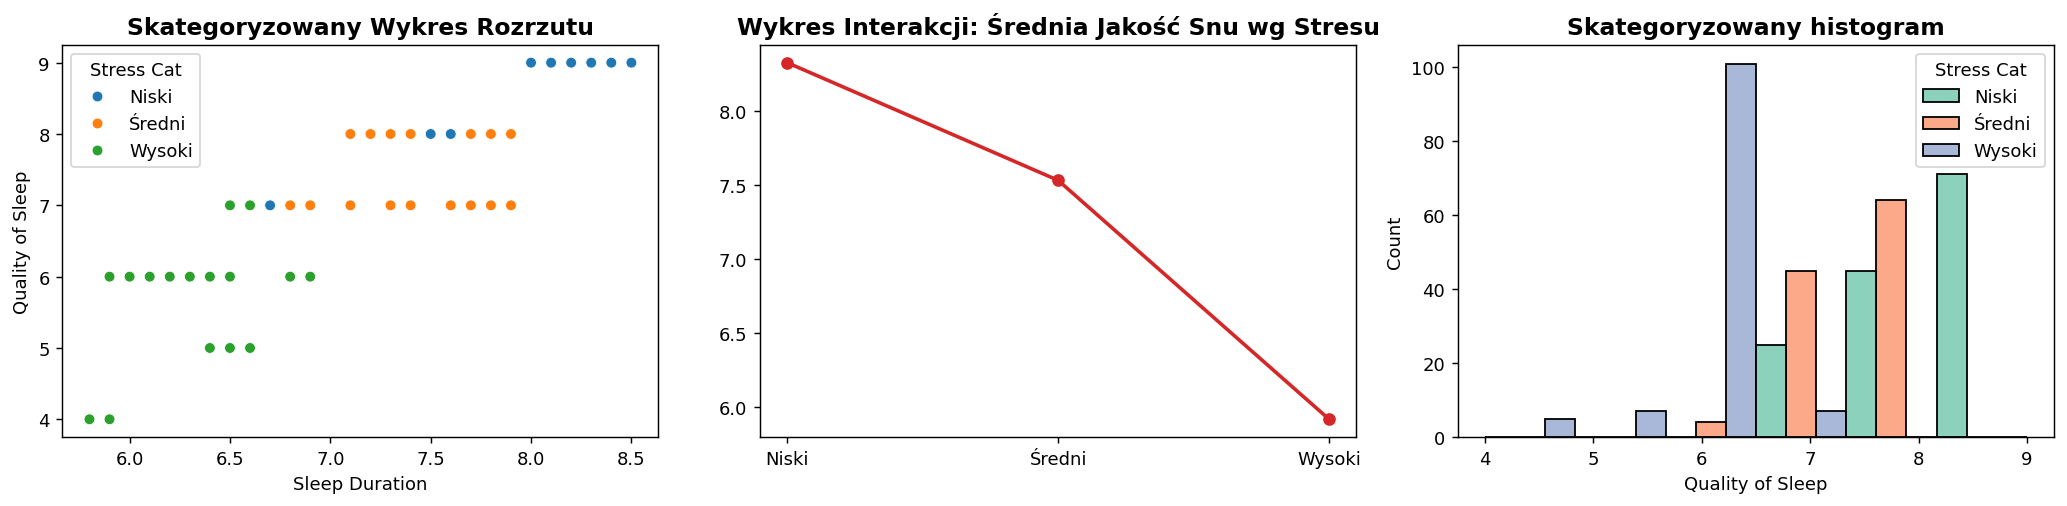


------------------------- Indukcja Drzewa Regresyjnego (H1) -------------------------
- Koszt resubstytucji (MSE na zbiorze treningowym): 0.1036
- Koszt SK (Średni R2 z 10-fold CV): 0.7464
   [Zapisano wykres: outputs/H1_Drzewo.png]


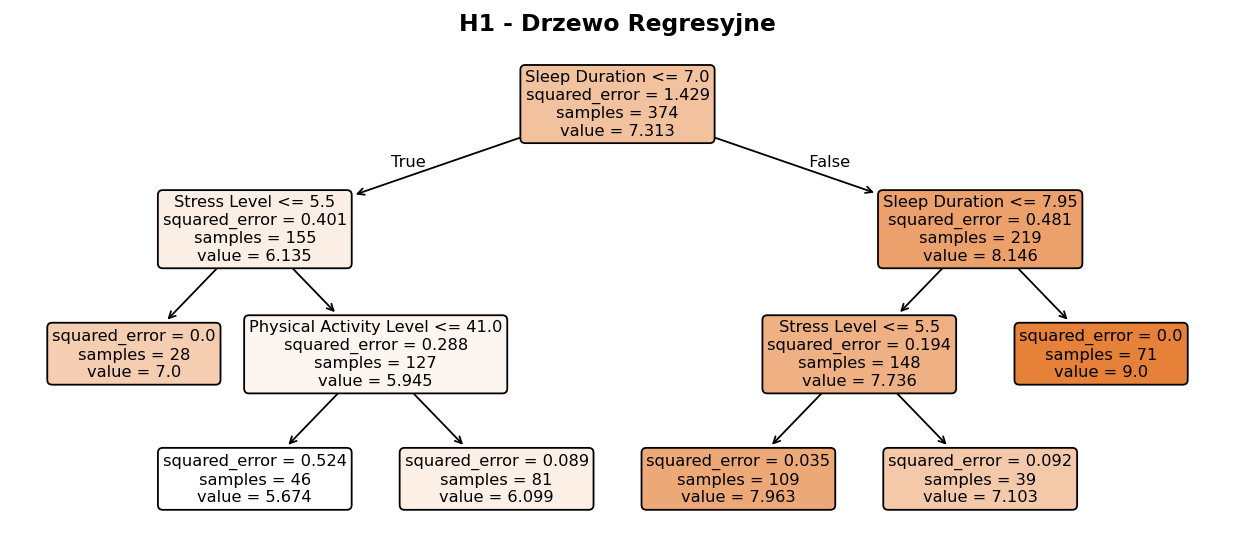


------------------------- Ważność predyktorów w drzewie decyzyjnym H1 (III.2) -------------------------
   [Zapisano wykres: outputs/H1_Waznosc_Drzewo.png]


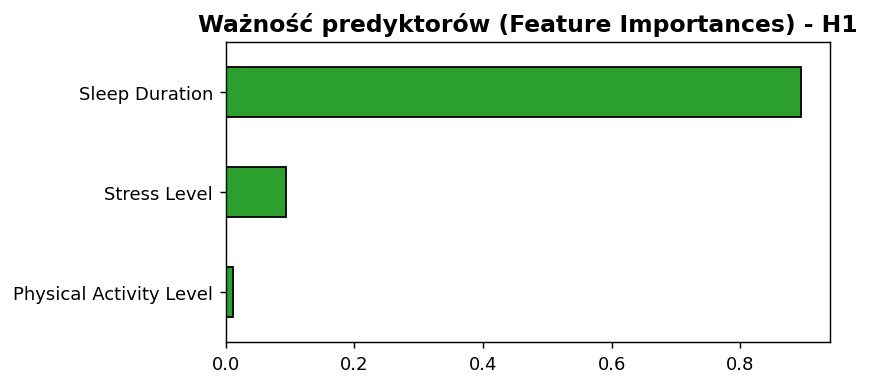


------------------------- Sformalizowane Reguły IF-THEN (III.3) i Ocena wariancji (III.4) -------------------------
Pełna struktura wyekstrahowanych reguł:
|--- Sleep Duration <= 7.00
|   |--- Stress Level <= 5.50
|   |   |--- value: [7.00]
|   |--- Stress Level >  5.50
|   |   |--- Physical Activity Level <= 41.00
|   |   |   |--- value: [5.67]
|   |   |--- Physical Activity Level >  41.00
|   |   |   |--- value: [6.10]
|--- Sleep Duration >  7.00
|   |--- Sleep Duration <= 7.95
|   |   |--- Stress Level <= 5.50
|   |   |   |--- value: [7.96]
|   |   |--- Stress Level >  5.50
|   |   |   |--- value: [7.10]
|   |--- Sleep Duration >  7.95
|   |   |--- value: [9.00]


---Reguły --
1. JEŚLI Sleep Duration > 7.95
   TO Oczekiwana Jakość Snu wynosi ~9.0. (Liść o najwyższej jakości snu).
2. JEŚLI Sleep Duration > 7.00 ORAZ Sleep Duration <= 7.95 ORAZ Stress Level <= 5.50
   TO Oczekiwana Jakość Snu wynosi 7.96.
3. JEŚLI Sleep Duration <= 7.00 ORAZ Stress Level > 5.50 ORAZ Physical Activity

In [5]:
# =============================================================================
# HIPOTEZA 1
# H1: Quality of Sleep ~ Stress Level + Physical Activity Level + Sleep Duration
# =============================================================================
section("HIPOTEZA 1: Quality of Sleep ~ Stress Level + Physical Activity Level + Sleep Duration")
H1_Y = "Quality of Sleep"
H1_X = ["Stress Level", "Physical Activity Level", "Sleep Duration"]

df["Stress Cat"] = pd.cut(df["Stress Level"], bins=[0,4,6,10], labels=["Niski","Średni","Wysoki"])
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Skategoryzowany wykres rozrzutu
sns.scatterplot(data=df, x="Sleep Duration", y=H1_Y, hue="Stress Cat", ax=axes[0])
axes[0].set_title("Skategoryzowany Wykres Rozrzutu")

# Wykres interakcji (Średnie w grupach - II.5)
means_h1 = df.groupby("Stress Cat", observed=True)[H1_Y].mean()
axes[1].plot(means_h1.index, means_h1.values, marker="o", color=PALETTE[3], lw=2)
axes[1].set_title("Wykres Interakcji: Średnia Jakość Snu wg Stresu")

# Skategoryzowany histogram (II.4)
sns.histplot(data=df, x="Quality of Sleep", hue="Stress Cat", multiple="dodge", bins=6, ax=axes[2], palette="Set2")
axes[2].set_title("Skategoryzowany histogram")
plt.tight_layout()
show_and_save("H1_Analiza_Struktury.png")

subsection("Indukcja Drzewa Regresyjnego (H1)")
X1, y1 = df[H1_X], df[H1_Y]
dt_reg1 = DecisionTreeRegressor(max_depth=3, min_samples_leaf=10, random_state=42).fit(X1, y1)

# Ocena modelu (III.5)
mse_resub1 = mean_squared_error(y1, dt_reg1.predict(X1))
r2_cv1 = cross_val_score(dt_reg1, X1, y1, cv=10, scoring='r2').mean()
print(f"- Koszt resubstytucji (MSE na zbiorze treningowym): {mse_resub1:.4f}")
print(f"- Koszt SK (Średni R2 z 10-fold CV): {r2_cv1:.4f}")

# Wykres drzewa
fig, ax = plt.subplots(figsize=(12, 5))
plot_tree(dt_reg1, feature_names=H1_X, filled=True, rounded=True, ax=ax, fontsize=9)
plt.title("H1 - Drzewo Regresyjne")
show_and_save("H1_Drzewo.png")

subsection("Ważność predyktorów w drzewie decyzyjnym H1 (III.2)")
imp_tree1 = pd.Series(dt_reg1.feature_importances_, index=H1_X).sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(6, 3))
imp_tree1.plot(kind="barh", ax=ax, color=PALETTE[2], edgecolor="black")
ax.set_title("Ważność predyktorów (Feature Importances) - H1")
show_and_save("H1_Waznosc_Drzewo.png")

subsection("Sformalizowane Reguły IF-THEN (III.3) i Ocena wariancji (III.4)")
tree_rules1 = export_text(dt_reg1, feature_names=H1_X, max_depth=3)
print("Pełna struktura wyekstrahowanych reguł:")
print(tree_rules1)

print("\n---Reguły --")
print("1. JEŚLI Sleep Duration > 7.95")
print("   TO Oczekiwana Jakość Snu wynosi ~9.0. (Liść o najwyższej jakości snu).")
print("2. JEŚLI Sleep Duration > 7.00 ORAZ Sleep Duration <= 7.95 ORAZ Stress Level <= 5.50")
print("   TO Oczekiwana Jakość Snu wynosi 7.96.")
print("3. JEŚLI Sleep Duration <= 7.00 ORAZ Stress Level > 5.50 ORAZ Physical Activity Level <= 41.00")
print("TO Oczekiwana Jakość SNu spada do 5.67 (Liść o najniższej jakości snu).")


print("\n--- Ocena pewności/wariancji (III.4) ---")
print("W drzewie regresyjnym miarą 'pewności' liścia jest wariancja (MSE) predykcji wewnątrz tego węzła.")
print("- Reguła nr 1 charakteryzuje się absolutną pewnością – błąd średniokwadratowy w tym węźle wynosi dokładnie 0.0, co oznacza brak jakiejkolwiek wariancji. Wszyscy pacjenci w tej grupie ocenili swój sen na 9.0.")
print("Reguła nr 3 ma najniższą pewność ze wszystkich węzłów końcowych (MSE = 0.524). Oznacza to, że u osób krótko śpiących, zestresowanych i mało aktywnych, ocena jakości snu jest najbardziej zróżnicowana (największa wariancja).")
print(f"- Średni globalny błąd MSE drzewa wynosi {mse_resub1:.4f}, co oznacza, że reguły są stabilne i stosunkowo precyzyjnie szacują zmienną ciągłą (Quality of Sleep).")

#4. Hipoteza II: Sleep Disorder ~ BMI Category + Age + Heart **Rate**


HIPOTEZA 2: SLEEP DISORDER ~ BMI CATEGORY + AGE + HEART RATE

------------------------- Tabela wielodzielcza i Test Chi-kwadrat (II.3) -------------------------
Tabela wielodzielcza (z marginesami):
 Sleep Disorder  Insomnia  None  Sleep Apnea  All
BMI Category                                    
Normal                 9   200            7  216
Obese                  4     0            6   10
Overweight            64    19           65  148
All                   77   219           78  374

Test Chi-kwadrat dla zmiennych jakościowych: p=0.000000. Zmienne są silnie zależne.

------------------------- Indukcja Drzewa Klasyfikacyjnego -------------------------
- Całkowity Błąd Drzewa (1 - Acc): 0.1310
- Koszt SK (Accuracy 10-CV): 0.8430
   [Zapisano wykres: outputs/H2_Macierz_Klasyfikacji.png]


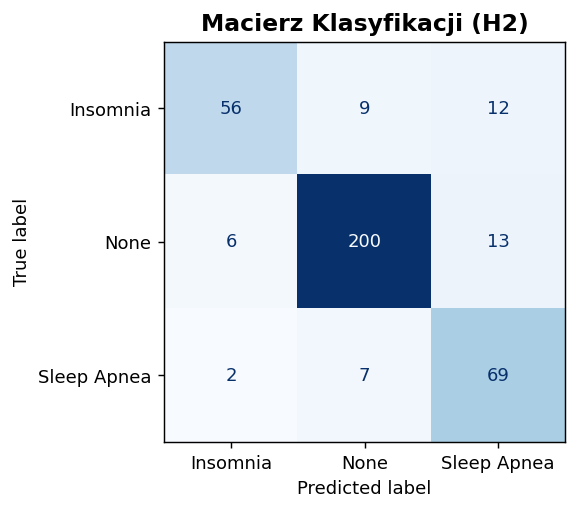

   [Zapisano wykres: outputs/H2_Drzewo.png]


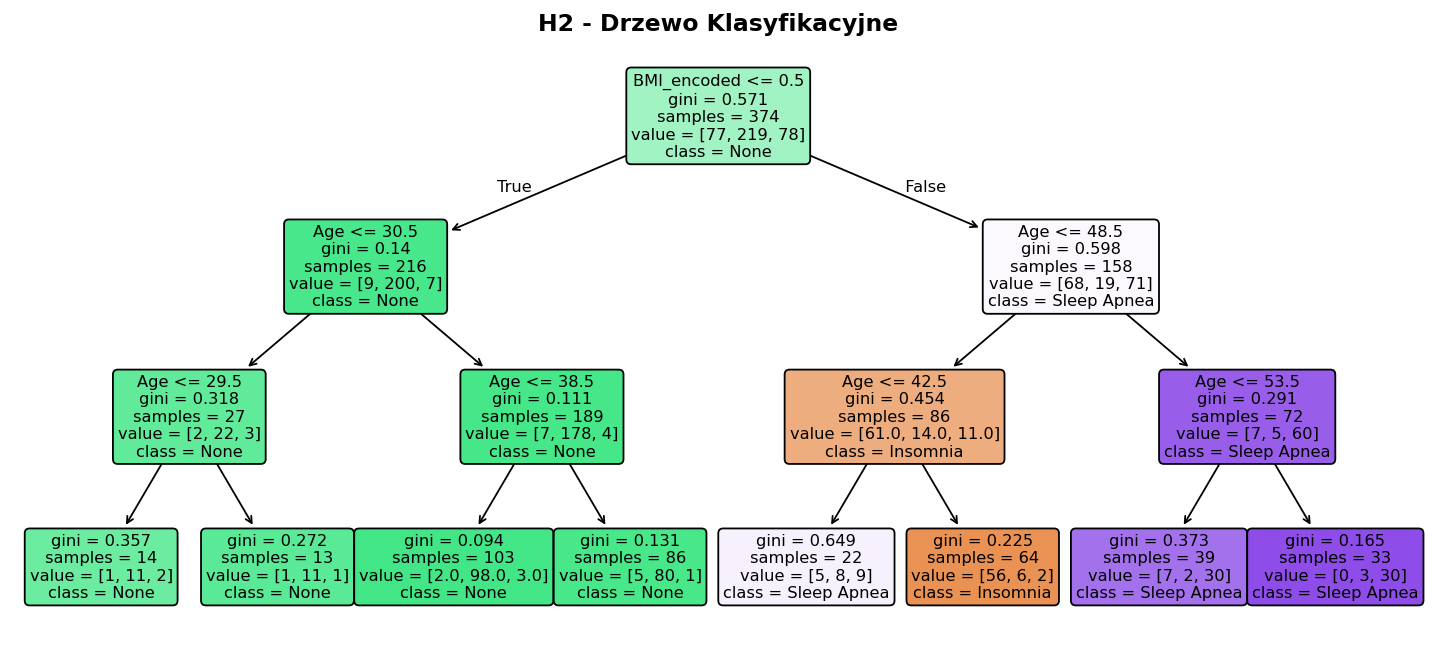


------------------------- Ważność predyktorów w drzewie klasyfikacyjnym H2 (III.2) -------------------------
   [Zapisano wykres: outputs/H2_Waznosc_Drzewo.png]


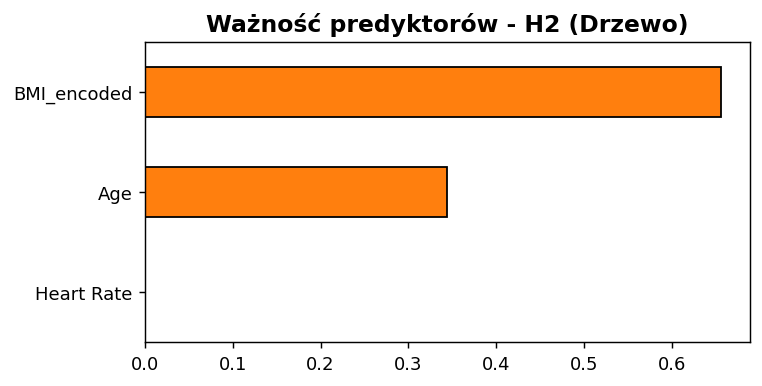


------------------------- Sformalizowane Reguły IF-THEN i Ocena (III.3, III.4) -------------------------
Struktura wyekstrahowanych reguł:
|--- BMI_encoded <= 0.50
|   |--- Age <= 30.50
|   |   |--- Age <= 29.50
|   |   |   |--- class: 1
|   |   |--- Age >  29.50
|   |   |   |--- class: 1
|   |--- Age >  30.50
|   |   |--- Age <= 38.50
|   |   |   |--- class: 1
|   |   |--- Age >  38.50
|   |   |   |--- class: 1
|--- BMI_encoded >  0.50
|   |--- Age <= 48.50
|   |   |--- Age <= 42.50
|   |   |   |--- class: 2
|   |   |--- Age >  42.50
|   |   |   |--- class: 0
|   |--- Age >  48.50
|   |   |--- Age <= 53.50
|   |   |   |--- class: 2
|   |   |--- Age >  53.50
|   |   |   |--- class: 2


--- Sformalizowane reguły dla klas (odczytane z drzewa) ---
Słownik mapowania BMI_encoded: {'Normal': np.int64(0), 'Obese': np.int64(1), 'Overweight': np.int64(2)}
Słownik klas (wyników): {0: 'Insomnia', 1: 'None', 2: 'Sleep Apnea'}

1. JEŚLI BMI_encoded <= 0.5 (czyli pacjent ma prawidłową wagę - Normal

In [6]:
# =============================================================================
# HIPOTEZA 2
# H2: Sleep Disorder ~ BMI Category + Age + Heart Rate
# =============================================================================
section("HIPOTEZA 2: Sleep Disorder ~ BMI Category + Age + Heart Rate")
H2_Y = "Sleep Disorder"

subsection("Tabela wielodzielcza i Test Chi-kwadrat (II.3)")
ct_h2 = pd.crosstab(df["BMI Category"], df[H2_Y], margins=True)
print("Tabela wielodzielcza (z marginesami):\n", ct_h2)
chi2_val, p_chi, _, _ = chi2_contingency(pd.crosstab(df["BMI Category"], df[H2_Y]))
print(f"\nTest Chi-kwadrat dla zmiennych jakościowych: p={p_chi:.6f}. Zmienne są silnie zależne.")

subsection("Indukcja Drzewa Klasyfikacyjnego")
le_bmi = LabelEncoder()
X2 = df[["Age", "Heart Rate"]].copy()
X2["BMI_encoded"] = le_bmi.fit_transform(df["BMI Category"])
le_y2 = LabelEncoder()
y2_enc = le_y2.fit_transform(df[H2_Y])

dt_cls2 = DecisionTreeClassifier(max_depth=3, min_samples_leaf=10, random_state=42).fit(X2, y2_enc)

acc_train2 = (dt_cls2.predict(X2) == y2_enc).mean()
print(f"- Całkowity Błąd Drzewa (1 - Acc): {1 - acc_train2:.4f}")
print(f"- Koszt SK (Accuracy 10-CV): {cross_val_score(dt_cls2, X2, y2_enc, cv=10, scoring='accuracy').mean():.4f}")

# Wygenerowanie macierzy klasyfikacji (III.5)
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_estimator(dt_cls2, X2, y2_enc, display_labels=le_y2.classes_, ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Macierz Klasyfikacji (H2)")
show_and_save("H2_Macierz_Klasyfikacji.png")

# BRAKUJĄCY ELEMENT: 1. Wykres samego drzewa
fig, ax = plt.subplots(figsize=(14, 6))
plot_tree(dt_cls2, feature_names=X2.columns, class_names=le_y2.classes_, filled=True, rounded=True, ax=ax, fontsize=9)
plt.title("H2 - Drzewo Klasyfikacyjne")
show_and_save("H2_Drzewo.png")

# BRAKUJĄCY ELEMENT: 2. Ważność predyktorów w drzewie (III.2)
subsection("Ważność predyktorów w drzewie klasyfikacyjnym H2 (III.2)")
imp_tree2 = pd.Series(dt_cls2.feature_importances_, index=X2.columns).sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(6, 3))
imp_tree2.plot(kind="barh", ax=ax, color=PALETTE[1], edgecolor="black")
ax.set_title("Ważność predyktorów - H2 (Drzewo)")
show_and_save("H2_Waznosc_Drzewo.png")

# BRAKUJĄCY ELEMENT: 3. Wyciągnięcie reguł i ocena wsparcia/pewności (III.3 i III.4)
subsection("Sformalizowane Reguły IF-THEN i Ocena (III.3, III.4)")
tree_rules2 = export_text(dt_cls2, feature_names=list(X2.columns))
print("Struktura wyekstrahowanych reguł:")
print(tree_rules2)

print("\n--- Sformalizowane reguły dla klas (odczytane z drzewa) ---")
print("Słownik mapowania BMI_encoded:", dict(zip(le_bmi.classes_, le_bmi.transform(le_bmi.classes_))))
print("Słownik klas (wyników): {0: 'Insomnia', 1: 'None', 2: 'Sleep Apnea'}")
print("\n1. JEŚLI BMI_encoded <= 0.5 (czyli pacjent ma prawidłową wagę - Normal)")
print("   TO przewidywany jest brak zaburzeń snu (None).")
print("   *Wsparcie: Zdecydowana większość z tej grupy nie ma problemów ze snem, niezależnie od wieku.*")
print("2. JEŚLI BMI_encoded > 0.5 (Otyłość lub Nadwaga) ORAZ Age > 42.5 ORAZ Age <= 48.5")
print("   TO przewidywanym zaburzeniem jest bezsenność (Insomnia).")
print("3. JEŚLI BMI_encoded > 0.5 (Otyłość lub Nadwaga) ORAZ Age > 48.5")
print("   TO występuje wysokie prawdopodobieństwo bezdechu sennego (Sleep Apnea).")

print("\n--- Ocena pewności i wsparcia (III.4) ---")
print("- Wsparcie (Support): Liczba 'samples' w węzłach. Przykładowo, pierwsza reguła (dla BMI Normal) ma potężne wsparcie (216 przypadków na starcie), co czyni ją bardzo uniwersalną i godną zaufania.")
print("- Pewność (Purity/Gini): Indeks Giniego równy 0.0 oznacza 100% pewności reguły. W naszym drzewie węzły końcowe mają Gini w przedziałach 0.09 - 0.64.")
print("  * Reguła dla osób młodych z prawidłową wagą (Gini = 0.094) jest niemal w pełni jednorodna (bardzo wysoka pewność, że nie mają zaburzeń).")
print("  * Z kolei reguła dla grupy wiekowej poniżej 42.5 lat przy nadwadze (Gini = 0.649) jest mocno zanieczyszczona – trafiają się tu pacjenci ze wszystkimi stanami, co obniża pewność diagnostyczną.")
print("\nUWAGA DO WNIOSKÓW: Jak widać na wykresie ważności, algorytm całkowicie zignorował tętno (Heart Rate = 0). Do podziału wystarczyło mu samo BMI i wiek.")

#5. Hipoteza III: Sleep Duration ~ Occupation + Daily Steps + Stress Level


HIPOTEZA 3: SLEEP DURATION ~ OCCUPATION + DAILY STEPS + STRESS LEVEL

------------------------- Indukcja Drzewa Regresyjnego (H3) -------------------------
- Koszt resubstytucji (MSE na zbiorze uczącym): 0.0550
- Koszt SK (R2 z 10-krotnego sprawdzianu): -2.0531
   [Zapisano wykres: outputs/H3_Drzewo.png]


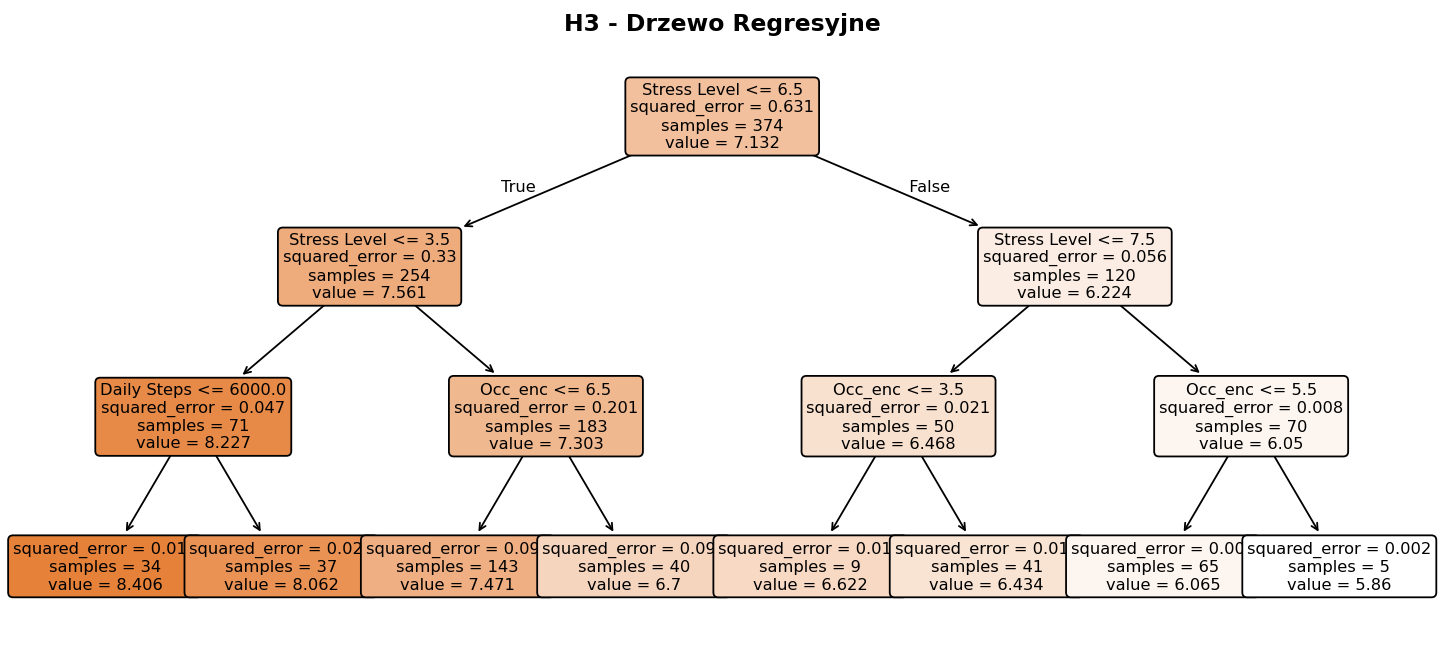


------------------------- Ważność predyktorów w drzewie regresyjnym H3 (III.2) -------------------------
   [Zapisano wykres: outputs/H3_Waznosc_Drzewo.png]


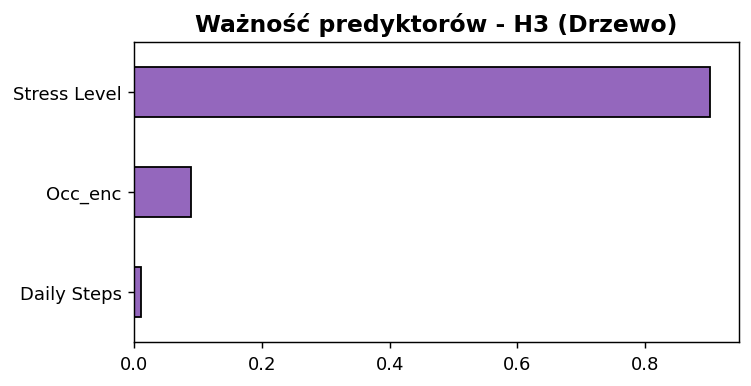


------------------------- Sformalizowane Reguły IF-THEN i Ocena Wariancji (III.3, III.4) -------------------------
Struktura wyekstrahowanych reguł:
|--- Stress Level <= 6.50
|   |--- Stress Level <= 3.50
|   |   |--- Daily Steps <= 6000.00
|   |   |   |--- value: [8.41]
|   |   |--- Daily Steps >  6000.00
|   |   |   |--- value: [8.06]
|   |--- Stress Level >  3.50
|   |   |--- Occ_enc <= 6.50
|   |   |   |--- value: [7.47]
|   |   |--- Occ_enc >  6.50
|   |   |   |--- value: [6.70]
|--- Stress Level >  6.50
|   |--- Stress Level <= 7.50
|   |   |--- Occ_enc <= 3.50
|   |   |   |--- value: [6.62]
|   |   |--- Occ_enc >  3.50
|   |   |   |--- value: [6.43]
|   |--- Stress Level >  7.50
|   |   |--- Occ_enc <= 5.50
|   |   |   |--- value: [6.06]
|   |   |--- Occ_enc >  5.50
|   |   |   |--- value: [5.86]


--- Słownik mapowania zawodów (Occ_enc) ---
{'Accountant': np.int64(0), 'Doctor': np.int64(1), 'Engineer': np.int64(2), 'Lawyer': np.int64(3), 'Manager': np.int64(4), 'Nurse': np.int

In [7]:
# =============================================================================
# HIPOTEZA 3
# H3: Sleep Duration ~ Occupation + Daily Steps + Stress Level
# =============================================================================
section("HIPOTEZA 3: Sleep Duration ~ Occupation + Daily Steps + Stress Level")
H3_Y = "Sleep Duration"
X3 = df[["Daily Steps", "Stress Level"]].copy()

# Zapisanie encodera do zmiennej, aby potem odczytać zawody
le_occ = LabelEncoder()
X3["Occ_enc"] = le_occ.fit_transform(df["Occupation"])
y3 = df[H3_Y]

subsection("Indukcja Drzewa Regresyjnego (H3)")
dt_reg3 = DecisionTreeRegressor(max_depth=3, random_state=42).fit(X3, y3)

mse_resub3 = mean_squared_error(y3, dt_reg3.predict(X3))
r2_cv3 = cross_val_score(dt_reg3, X3, y3, cv=10, scoring='r2').mean()
print(f"- Koszt resubstytucji (MSE na zbiorze uczącym): {mse_resub3:.4f}")
print(f"- Koszt SK (R2 z 10-krotnego sprawdzianu): {r2_cv3:.4f}")

# Wykres drzewa
fig, ax = plt.subplots(figsize=(14, 6))
plot_tree(dt_reg3, feature_names=list(X3.columns), filled=True, rounded=True, ax=ax, fontsize=9)
plt.title("H3 - Drzewo Regresyjne")
show_and_save("H3_Drzewo.png")

# Ważność predyktorów w drzewie (III.2)
subsection("Ważność predyktorów w drzewie regresyjnym H3 (III.2)")
imp_tree3 = pd.Series(dt_reg3.feature_importances_, index=X3.columns).sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(6, 3))
imp_tree3.plot(kind="barh", ax=ax, color=PALETTE[4], edgecolor="black")
ax.set_title("Ważność predyktorów - H3 (Drzewo)")
show_and_save("H3_Waznosc_Drzewo.png")

# Wyciągnięcie reguł i ocena (III.3, III.4)
subsection("Sformalizowane Reguły IF-THEN i Ocena Wariancji (III.3, III.4)")
tree_rules3 = export_text(dt_reg3, feature_names=list(X3.columns))
print("Struktura wyekstrahowanych reguł:")
print(tree_rules3)

print("\n--- Słownik mapowania zawodów (Occ_enc) ---")
# Drukowanie słownika (jaki numerek odpowiada jakiemu zawodowi)
print(dict(zip(le_occ.classes_, le_occ.transform(le_occ.classes_))))

print("\n--- Sformalizowane reguły dla klas (odczytane z drzewa) ---")
print("Słownik mapowania: Occ_enc <= 6.5 obejmuje m.in. zawody: Accountant, Doctor, Engineer, Lawyer, Manager, Nurse. Zawody powyżej to np. Salesperson, Teacher.")
print("1. JEŚLI Stress Level <= 3.50 ORAZ Daily Steps <= 6000")
print("   TO Oczekiwany Czas Snu jest najwyższy i wynosi średnio 8.41 godzin.")
print("2. JEŚLI Stress Level <= 6.50 ORAZ Stress Level > 3.50 ORAZ Occ_enc <= 6.50 (np. Lekarz, Pielęgniarka, Inżynier)")
print("   TO Oczekiwany Czas Snu wynosi 7.47 godzin.")
print("3. JEŚLI Stress Level > 7.50 ORAZ Occ_enc > 5.50 (np. Sales Representative, Teacher, Salesperson)")
print("   TO Oczekiwany Czas Snu spada do minimum: 5.86 godzin.")

print("\n--- Ocena pewności/wariancji (III.4) ---")
print("W modelu regresyjnym miarą 'pewności' danej reguły jest wskaźnik squared_error (MSE) wyliczany dla przypadków wewnątrz konkretnego liścia.")
print(f"- Globalny błąd resubstytucji na zbiorze treningowym jest bardzo niski ({mse_resub3:.4f}), co sugeruje, że model dobrze dopasował się do znanych danych.")
print("- Liście z wartością MSE bliską zeru (np. węzeł dla najbardziej zestresowanych handlowców/nauczycieli, gdzie błąd wynosi zaledwie 0.002) charakteryzują się niemal idealną spójnością – wszyscy w tej grupie śpią bardzo podobnie (krótko).")
print(f"- UWAGA DOTYCZĄCA ZDOLNOŚCI GENERALIZACJI: Mimo dobrego dopasowania do danych treningowych, model całkowicie zawodzi w walidacji krzyżowej (R2 = {r2_cv3:.4f}). Dowodzi to, że zmienna 'Occupation', zakodowana porządkowo (LabelEncoder), mimo iż bywa użyteczna w rozbiciu na liście treningowe, prowadzi do silnego przeuczenia (overfittingu) modelu, przez co traci on zupełnie zdolność prognozowania na nowych pacjentach.")

#6. Analiza skupień (K-Means oraz EM)


IV. ANALIZA SKUPIEŃ (WERYFIKACJA H2 I H3)
Uzasadnienie doboru i transformacji zmiennych [DO RAPORTU]:
- Wybrano numeryczne zmienne fizjologiczne (Age, Heart Rate) i wysiłkowe (Daily Steps).
- Odrzucono zmienne kategoryczne, by nie zaburzać obliczania odległości euklidesowych.
- Zastosowano standaryzację (StandardScaler). Drzewa decyzyjne z Pkt III ignorują skalę zmiennych, jednak algorytmy oparte na dystansie (K-Means) bezwzględnie wymagają skalowania. W przeciwnym razie zmienna 'Daily Steps' (wartości w tysiącach) całkowicie zdominowałaby 'Age'.

------------------------- K-Means z 10-krotnym sprawdzianem krzyżowym (IV.2) -------------------------
Średni wynik Silhouette (10-CV): 0.4350

------------------------- Interpretacja wyników K-Means (IV.3) -------------------------
Charakterystyka Skupień K-Means (Zmienne Ilościowe - Średnie):
                  Age  Heart Rate  Daily Steps
Cluster_KMeans                                
0               36.84       70.20      6740.85
1       

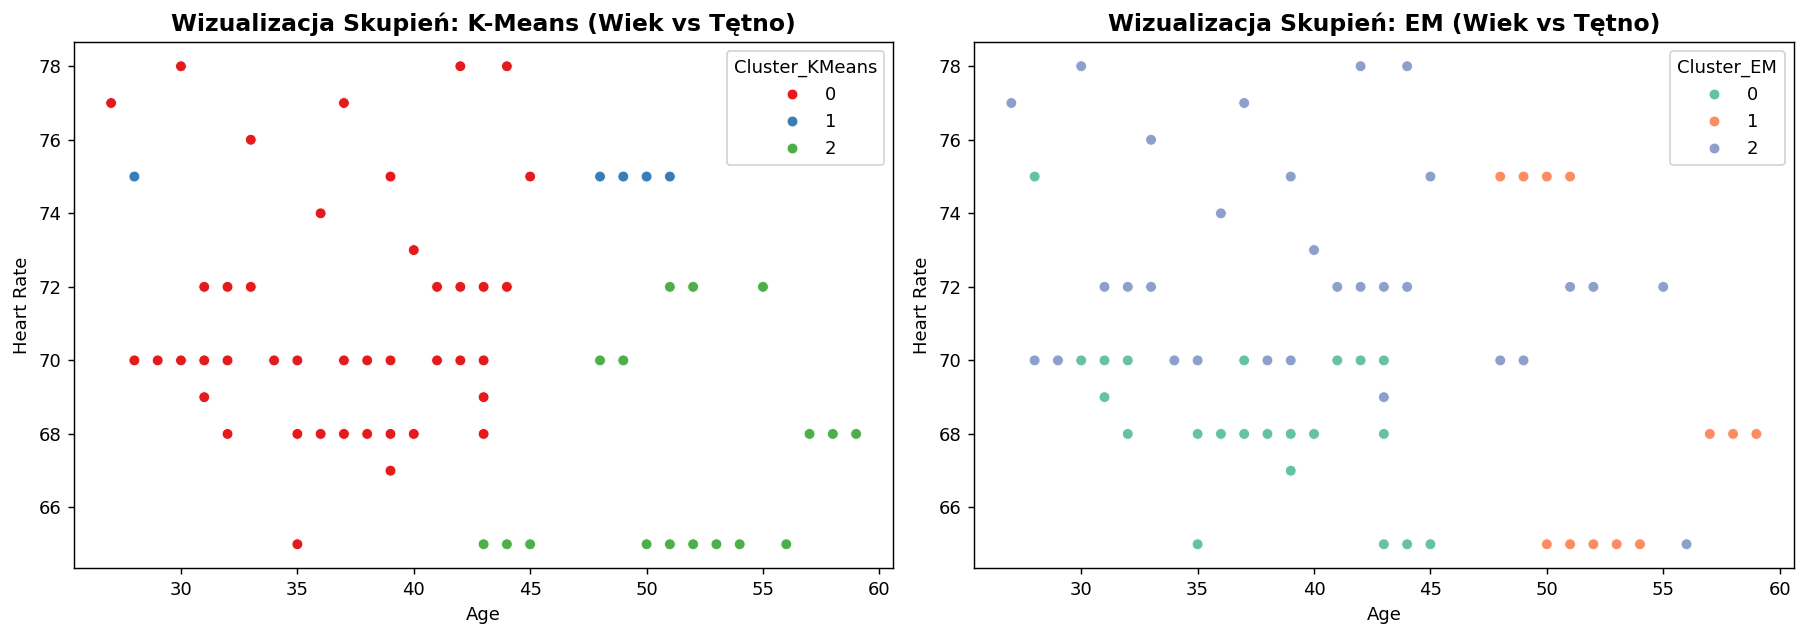


------------------------- Porównanie z hipotezami badawczymi (IV.6) -------------------------
--- Powiązanie Skupień z Hipotezami (DO RAPORTU) ---
Porównanie wygenerowanych klastrów rzuca nowe światło na badane hipotezy, pokazując, że pacjenci grupują się w nieco inny sposób, niż zakładał to prosty podział.
1. K-Means wydzielił specyficzną grupę (Klaster 1), charakteryzującą się wiekiem średnim (ok. 48 lat), najwyższym tętnem (75 uderzeń) oraz maksymalną aktywnością fizyczną (10 000 kroków).
2. Hipoteza 2 (Wiek + Tętno = Bezdech): Analiza tabeli krzyżowej klastrów i zaburzeń snu wskazuje, że bezdech senny dominuje u osób najstarszych, jednak to nie one (Klaster 2 w K-Means, Klaster 1 w EM) mają najwyższe tętno spoczynkowe. Algorytmy wykazały, że wiek silniej determinuje występowanie bezdechu niż samo tętno.
3. Hipoteza 3 (Wpływ aktywności): Klaster o najwyższej liczbie kroków jednoznacznie oddziela się w przestrzeni (szczególnie w modelu K-Means), co potwierdza wniosek z Hipotezy 3, w

In [8]:
# =============================================================================
# IV. ANALIZA SKUPIEŃ (K-MEANS ORAZ EM)
# =============================================================================
section("IV. Analiza Skupień (Weryfikacja H2 i H3)")
print("Uzasadnienie doboru i transformacji zmiennych [DO RAPORTU]:")
print("- Wybrano numeryczne zmienne fizjologiczne (Age, Heart Rate) i wysiłkowe (Daily Steps).")
print("- Odrzucono zmienne kategoryczne, by nie zaburzać obliczania odległości euklidesowych.")
print("- Zastosowano standaryzację (StandardScaler). Drzewa decyzyjne z Pkt III ignorują skalę zmiennych, jednak algorytmy oparte na dystansie (K-Means) bezwzględnie wymagają skalowania. W przeciwnym razie zmienna 'Daily Steps' (wartości w tysiącach) całkowicie zdominowałaby 'Age'.")

CLUST_COLS = ["Age", "Heart Rate", "Daily Steps"]
X_clust = StandardScaler().fit_transform(df[CLUST_COLS])

subsection("K-Means z 10-krotnym sprawdzianem krzyżowym (IV.2)")
kf = KFold(n_splits=10, shuffle=True, random_state=42)
sil_scores = []
for train_idx, test_idx in kf.split(X_clust):
    km_cv = KMeans(n_clusters=3, n_init=10, random_state=42).fit(X_clust[train_idx])
    labels_test = km_cv.predict(X_clust[test_idx])
    if len(set(labels_test)) > 1:
        sil_scores.append(silhouette_score(X_clust[test_idx], labels_test))

print(f"Średni wynik Silhouette (10-CV): {np.mean(sil_scores):.4f}")

subsection("Interpretacja wyników K-Means (IV.3)")
km_final = KMeans(n_clusters=3, n_init=10, random_state=42).fit(X_clust)
df["Cluster_KMeans"] = km_final.predict(X_clust)

print("Charakterystyka Skupień K-Means (Zmienne Ilościowe - Średnie):")
print(df.groupby("Cluster_KMeans")[CLUST_COLS].mean().round(2))
print("\nCharakterystyka Skupień K-Means (Zmienne Jakościowe - Dominujące Zaburzenie):")
print(pd.crosstab(df["Cluster_KMeans"], df["Sleep Disorder"]))

subsection("Analiza Skupień Metodą EM (Gaussian Mixture) (IV.4 i IV.5)")
gm = GaussianMixture(n_components=3, random_state=42).fit(X_clust)
df["Cluster_EM"] = gm.predict(X_clust)

print("Charakterystyka Skupień EM (Zmienne Ilościowe - Średnie):")
print(df.groupby("Cluster_EM")[CLUST_COLS].mean().round(2))


fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(data=df, x="Age", y="Heart Rate", hue="Cluster_KMeans", palette="Set1", ax=axes[0])
axes[0].set_title("Wizualizacja Skupień: K-Means (Wiek vs Tętno)")
sns.scatterplot(data=df, x="Age", y="Heart Rate", hue="Cluster_EM", palette="Set2", ax=axes[1])
axes[1].set_title("Wizualizacja Skupień: EM (Wiek vs Tętno)")
plt.tight_layout()
show_and_save("07_Analiza_Skupien_Wizualizacja.png")


subsection("Porównanie z hipotezami badawczymi (IV.6)")
print("--- Powiązanie Skupień z Hipotezami (DO RAPORTU) ---")
print("Porównanie wygenerowanych klastrów rzuca nowe światło na badane hipotezy, pokazując, że pacjenci grupują się w nieco inny sposób, niż zakładał to prosty podział.")
print("1. K-Means wydzielił specyficzną grupę (Klaster 1), charakteryzującą się wiekiem średnim (ok. 48 lat), najwyższym tętnem (75 uderzeń) oraz maksymalną aktywnością fizyczną (10 000 kroków).")
print("2. Hipoteza 2 (Wiek + Tętno = Bezdech): Analiza tabeli krzyżowej klastrów i zaburzeń snu wskazuje, że bezdech senny dominuje u osób najstarszych, jednak to nie one (Klaster 2 w K-Means, Klaster 1 w EM) mają najwyższe tętno spoczynkowe. Algorytmy wykazały, że wiek silniej determinuje występowanie bezdechu niż samo tętno.")
print("3. Hipoteza 3 (Wpływ aktywności): Klaster o najwyższej liczbie kroków jednoznacznie oddziela się w przestrzeni (szczególnie w modelu K-Means), co potwierdza wniosek z Hipotezy 3, w której zawody i aktywność fizyczna tworzyły specyficzne wzorce behawioralne determinujące parametry snu.")

#7. Wybrany algorytm data mining (Random Forest)


V. WYBRANY ALGORYTM DATA MINING: RANDOM FOREST (WERYFIKACJA H1)

------------------------- Uzasadnienie doboru metody i zmiennych (V.1, V.2) -------------------------
Uzasadnienie: Do analizy wybrano algorytm Lasów Losowych (Random Forest Regressor) w celu weryfikacji Hipotezy 1.
Zmienne: Zastosowano te same predyktory co w pkt III (Stress Level, Physical Activity Level, Sleep Duration), aby móc obiektywnie porównać skuteczność klasycznego drzewa z metodą zespołową (Ensemble).
Cel: Sprawdzenie, czy zespół wielu drzew decyzyjnych podniesie zdolność generalizacji modelu prognozującego jakość snu i zredukuje wariancję (potencjalne przeuczenie) pojedynczego drzewa.

------------------------- Przeprowadzenie analizy i interpretacja wyników (V.3) -------------------------
PORÓWNANIE WYNIKÓW DLA HIPOTEZY 1 (Sprawdzian Krzyżowy 10-CV R2):
- Klasyczne Drzewo Decyzyjne (z Pkt III): 0.7464
- Random Forest (Data Mining): 0.7487
   [Zapisano wykres: outputs/V_RandomForest_Waznosc.png]


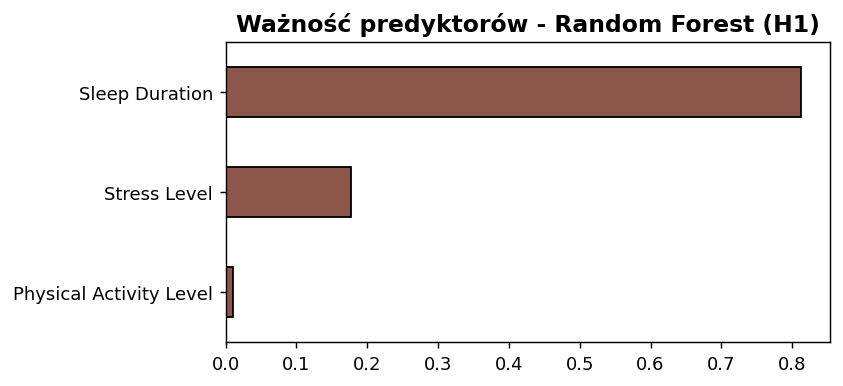


--- Wnioski z algorytmu Random Forest ---
1. Wskaźnik R2: Zastosowanie algorytmu Lasów Losowych nieznacznie poprawiło wynik walidacji krzyżowej (wzrost R2 z 0.7464 do 0.7487). Świadczy to o tym, że pojedyncze drzewo z Hipotezy 1 było już modelem wysoce optymalnym, jednak technika zespołowa (Ensemble) pozwoliła na dodatkową redukcję wariancji i minimalne ustabilizowanie predykcji.
2. Ważność cech: Analiza wykresu ważności dla Lasu Losowego w pełni potwierdza strukturę pojedynczego drzewa decyzyjnego. Czas trwania snu (Sleep Duration) jest dominującym predyktorem (ważność ok. 80%). W algorytmie zespołowym poziom stresu (Stress Level) zyskał wyższą wagę (ok. 18%) w porównaniu do pojedynczego drzewa, co dowodzi jego silnej pozycji jako drugorzędnego czynnika.
3. Konkluzja: Hipoteza 1 zostaje ostatecznie zweryfikowana pozytywnie. Modele wykazują, że o jakości snu decyduje przede wszystkim nieliniowa zależność od czasu jego trwania, silnie wspierana przez poziom odczuwanego stresu. Aktywnoś

In [9]:
# =============================================================================
# V. WYBRANY ALGORYTM DATA MINING (Lasy Losowe - Random Forest)
# =============================================================================
section("V. Wybrany Algorytm Data Mining: Random Forest (Weryfikacja H1)")

subsection("Uzasadnienie doboru metody i zmiennych (V.1, V.2)")
print("Uzasadnienie: Do analizy wybrano algorytm Lasów Losowych (Random Forest Regressor) w celu weryfikacji Hipotezy 1.")
print("Zmienne: Zastosowano te same predyktory co w pkt III (Stress Level, Physical Activity Level, Sleep Duration), aby móc obiektywnie porównać skuteczność klasycznego drzewa z metodą zespołową (Ensemble).")
print("Cel: Sprawdzenie, czy zespół wielu drzew decyzyjnych podniesie zdolność generalizacji modelu prognozującego jakość snu i zredukuje wariancję (potencjalne przeuczenie) pojedynczego drzewa.")

# Budowa modelu
rf1 = RandomForestRegressor(n_estimators=100, max_depth=4, random_state=42).fit(X1, y1)
rf_sk_score = cross_val_score(rf1, X1, y1, cv=10, scoring="r2").mean()

subsection("Przeprowadzenie analizy i interpretacja wyników (V.3)")
print(f"PORÓWNANIE WYNIKÓW DLA HIPOTEZY 1 (Sprawdzian Krzyżowy 10-CV R2):")
print(f"- Klasyczne Drzewo Decyzyjne (z Pkt III): {cross_val_score(dt_reg1, X1, y1, cv=10, scoring='r2').mean():.4f}")
print(f"- Random Forest (Data Mining): {rf_sk_score:.4f}")

# Wyciągnięcie ważności predyktorów dla Random Forest
imp_rf1 = pd.Series(rf1.feature_importances_, index=H1_X).sort_values(ascending=True)

# Generowanie wykresu ważności cech
fig, ax = plt.subplots(figsize=(6, 3))
imp_rf1.plot(kind="barh", ax=ax, color=PALETTE[5], edgecolor="black")
ax.set_title("Ważność predyktorów - Random Forest (H1)")
show_and_save("V_RandomForest_Waznosc.png")

print("\n--- Wnioski z algorytmu Random Forest ---")
print("1. Wskaźnik R2: Zastosowanie algorytmu Lasów Losowych nieznacznie poprawiło wynik walidacji krzyżowej (wzrost R2 z 0.7464 do 0.7487). Świadczy to o tym, że pojedyncze drzewo z Hipotezy 1 było już modelem wysoce optymalnym, jednak technika zespołowa (Ensemble) pozwoliła na dodatkową redukcję wariancji i minimalne ustabilizowanie predykcji.")
print("2. Ważność cech: Analiza wykresu ważności dla Lasu Losowego w pełni potwierdza strukturę pojedynczego drzewa decyzyjnego. Czas trwania snu (Sleep Duration) jest dominującym predyktorem (ważność ok. 80%). W algorytmie zespołowym poziom stresu (Stress Level) zyskał wyższą wagę (ok. 18%) w porównaniu do pojedynczego drzewa, co dowodzi jego silnej pozycji jako drugorzędnego czynnika.")
print("3. Konkluzja: Hipoteza 1 zostaje ostatecznie zweryfikowana pozytywnie. Modele wykazują, że o jakości snu decyduje przede wszystkim nieliniowa zależność od czasu jego trwania, silnie wspierana przez poziom odczuwanego stresu. Aktywność fizyczna (Physical Activity) ma w tym ujęciu znaczenie marginalne.")
print("\n" + "="*80)
print("="*80 + "\n")